In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway
import itertools

# For model predicton
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

In [26]:
# Eating Habit variables:
# FAVC = Frequence consumption of high caloric food
# FCVC = Frequency of consumption of vegetables
# NCP = Number of main meals
# CAEC = Consumption of food between meals 
# CH20 = Consumption of water daily
# CALC = Consumption of alcohol

# Physical condition variables:
# SCC = Calories consumption monitoring
# FAF = Physical activity frequency
# TUE = Time using technology devices
# MTRANS = Transportation used

df_train = pd.read_csv("train.csv")

df_test = pd.read_csv("test.csv")

ids = df_test["id"]

In [27]:
df_train

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,20753,Male,25.137087,1.766626,114.187096,yes,yes,2.919584,3.000000,Sometimes,no,2.151809,no,1.330519,0.196680,Sometimes,Public_Transportation,Obesity_Type_II
20754,20754,Male,18.000000,1.710000,50.000000,no,yes,3.000000,4.000000,Frequently,no,1.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Insufficient_Weight
20755,20755,Male,20.101026,1.819557,105.580491,yes,yes,2.407817,3.000000,Sometimes,no,2.000000,no,1.158040,1.198439,no,Public_Transportation,Obesity_Type_II
20756,20756,Male,33.852953,1.700000,83.520113,yes,yes,2.671238,1.971472,Sometimes,no,2.144838,no,0.000000,0.973834,no,Automobile,Overweight_Level_II


In [28]:
df_test

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,20758,Male,26.899886,1.848294,120.644178,yes,yes,2.938616,3.000000,Sometimes,no,2.825629,no,0.855400,0.000000,Sometimes,Public_Transportation
1,20759,Female,21.000000,1.600000,66.000000,yes,yes,2.000000,1.000000,Sometimes,no,3.000000,no,1.000000,0.000000,Sometimes,Public_Transportation
2,20760,Female,26.000000,1.643355,111.600553,yes,yes,3.000000,3.000000,Sometimes,no,2.621877,no,0.000000,0.250502,Sometimes,Public_Transportation
3,20761,Male,20.979254,1.553127,103.669116,yes,yes,2.000000,2.977909,Sometimes,no,2.786417,no,0.094851,0.000000,Sometimes,Public_Transportation
4,20762,Female,26.000000,1.627396,104.835346,yes,yes,3.000000,3.000000,Sometimes,no,2.653531,no,0.000000,0.741069,Sometimes,Public_Transportation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13835,34593,Male,23.327836,1.721384,78.030383,yes,no,2.813234,3.000000,Sometimes,no,1.000000,no,0.807076,0.778632,Sometimes,Public_Transportation
13836,34594,Female,29.000000,1.590000,62.000000,no,yes,3.000000,3.000000,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation
13837,34595,Female,22.935612,1.585547,44.376637,no,yes,3.000000,2.273740,Frequently,no,2.000000,no,1.949840,1.000000,Sometimes,Public_Transportation
13838,34596,Male,21.000000,1.620000,53.000000,yes,yes,2.000000,3.000000,Sometimes,no,2.000000,no,3.000000,2.000000,no,Public_Transportation


In [29]:
# Data cleaning : Not much cleaning has to be done as no null and duplicate values
print(df_train.isnull().sum())
print(df_train.duplicated().sum())

df_train = df_train.dropna()
df_train = df_train.drop_duplicates()

# Feature Engineering : BMI = weight (kg) / height (m^2) since data uses metric units
df_train["BMI"] = df_train["Weight"] / (df_train["Height"] ** 2)
df_test["BMI"] = df_test["Weight"] / (df_test["Height"] ** 2)

id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
0


In [30]:
# Encode obesity level as an ordered category
order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III"
]
df_train["obesity_cat"] = pd.Categorical(df_train["NObeyesdad"], categories=order, ordered=True)

# Numeric variables
num_preds = ["Age", "BMI", "FCVC", "NCP", "CH2O", "FAF", "TUE"] 

# Categorical variables
cat_preds = ["Gender", "family_history_with_overweight", "FAVC", "CAEC", "SMOKE", "SCC", "CALC", "MTRANS", "obesity_cat"]

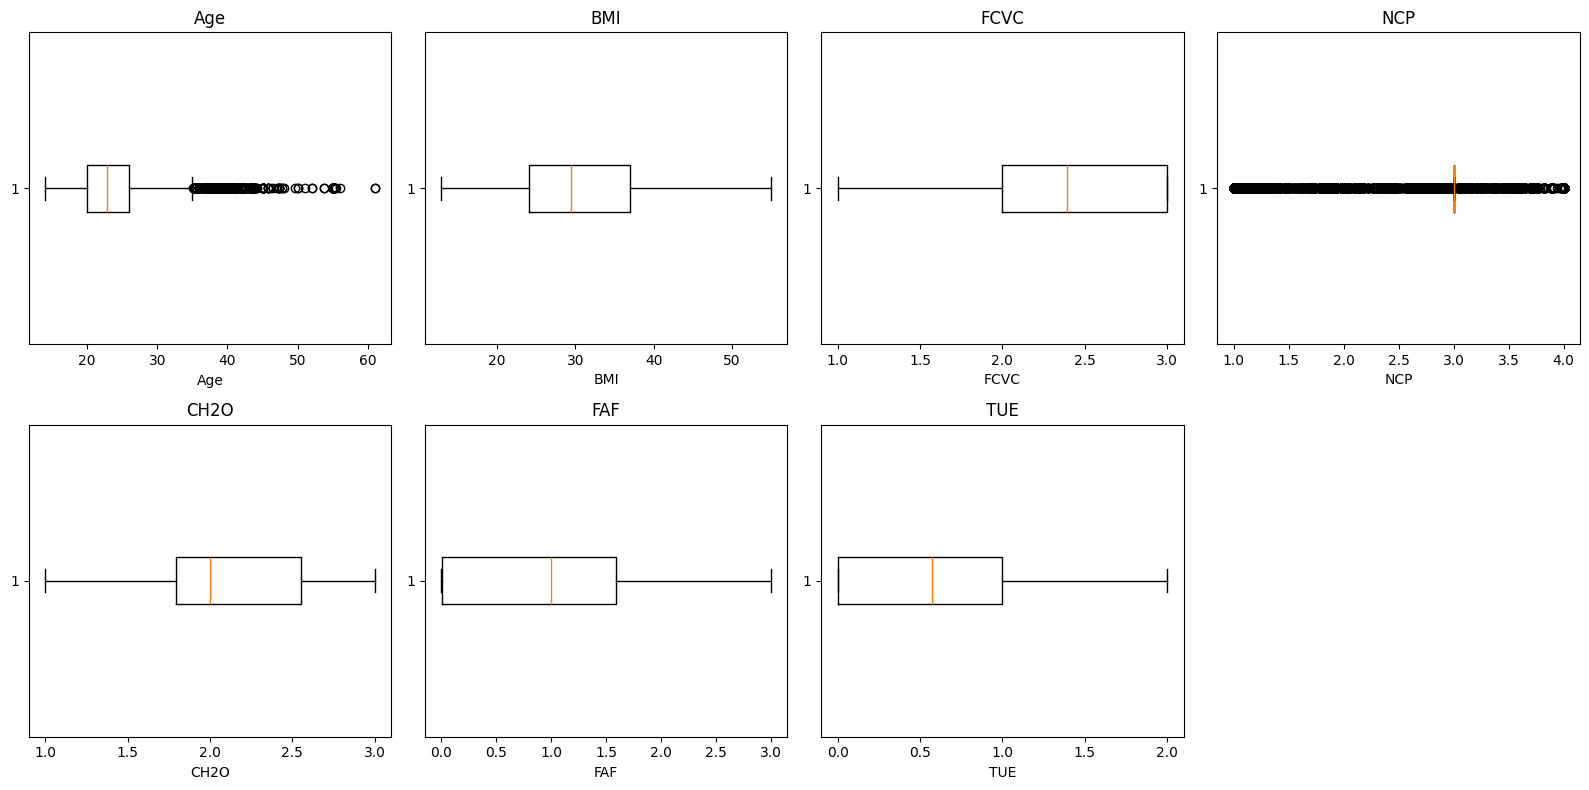

In [31]:
# Create 2x4 grid of boxplots
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(num_preds):
    axes[i].boxplot(df_train[var].dropna(), vert=False)
    axes[i].set_title(var)
    axes[i].set_xlabel(var)

# Hide any unused subplot (8th position)
if len(num_preds) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

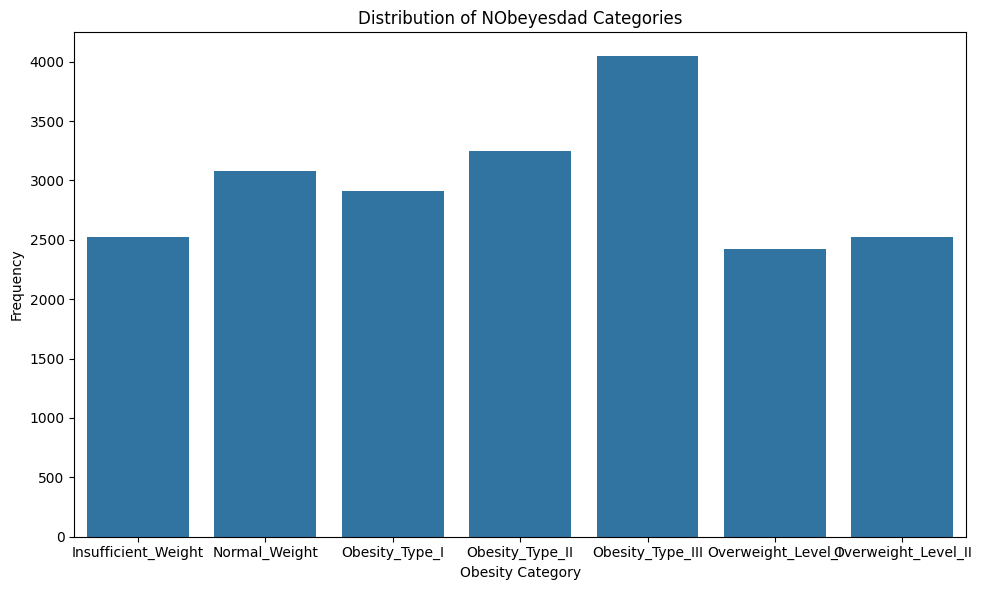

In [32]:
# Distribution Of Obesity Category
response_counts = df_train["NObeyesdad"].value_counts().sort_index()
plt.figure(figsize=(10,6))
sns.barplot(x=response_counts.index, y=response_counts.values)
plt.title("Distribution of NObeyesdad Categories")
# plt.xticks(rotation=45, ha="right")
plt.xlabel("Obesity Category")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

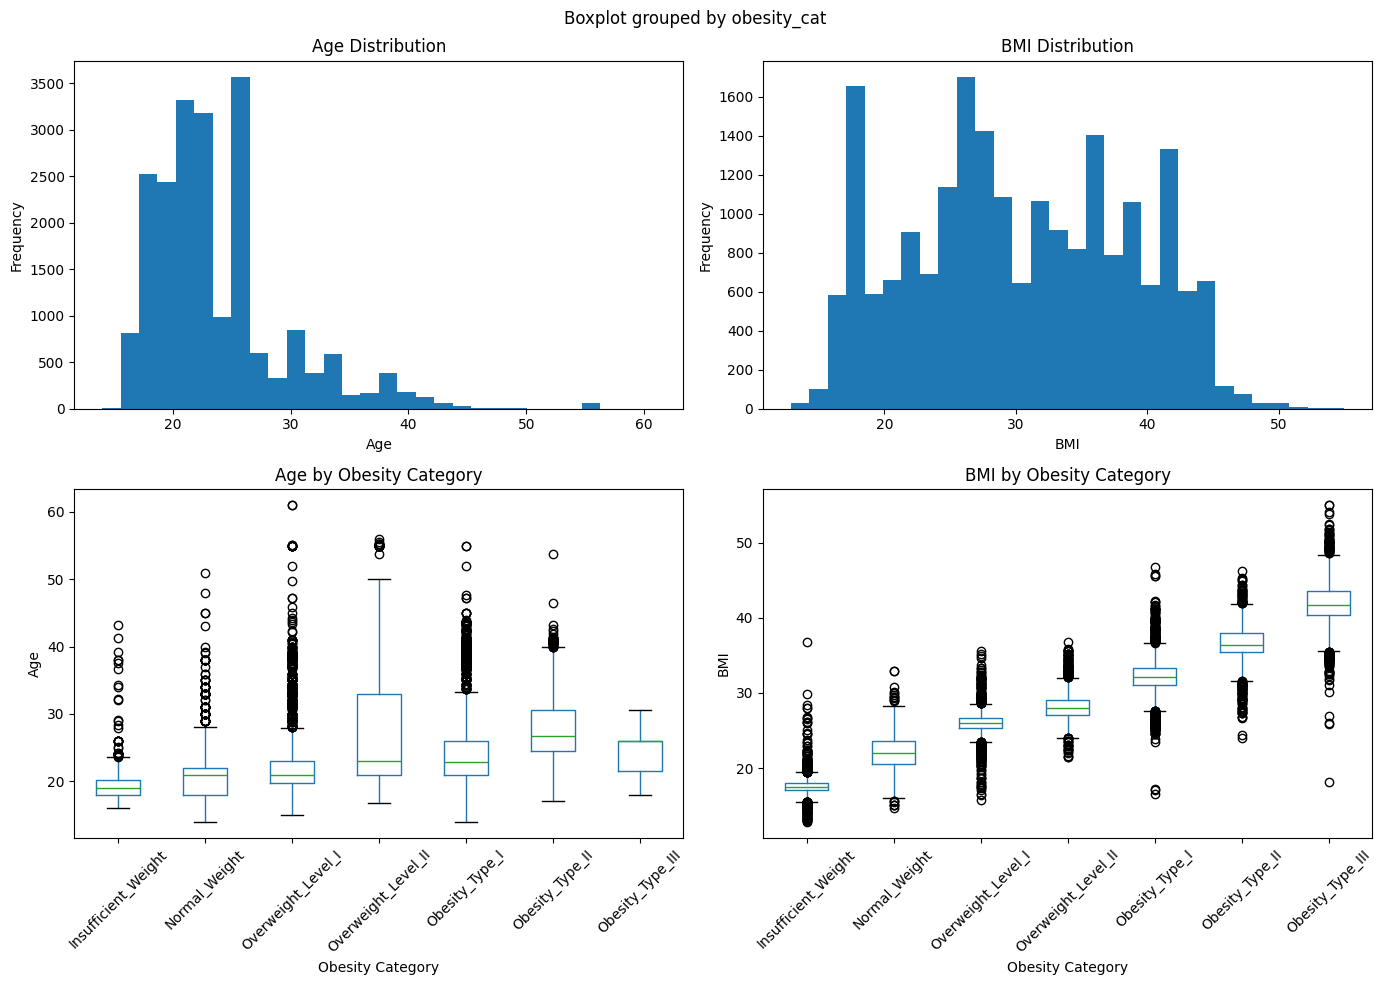

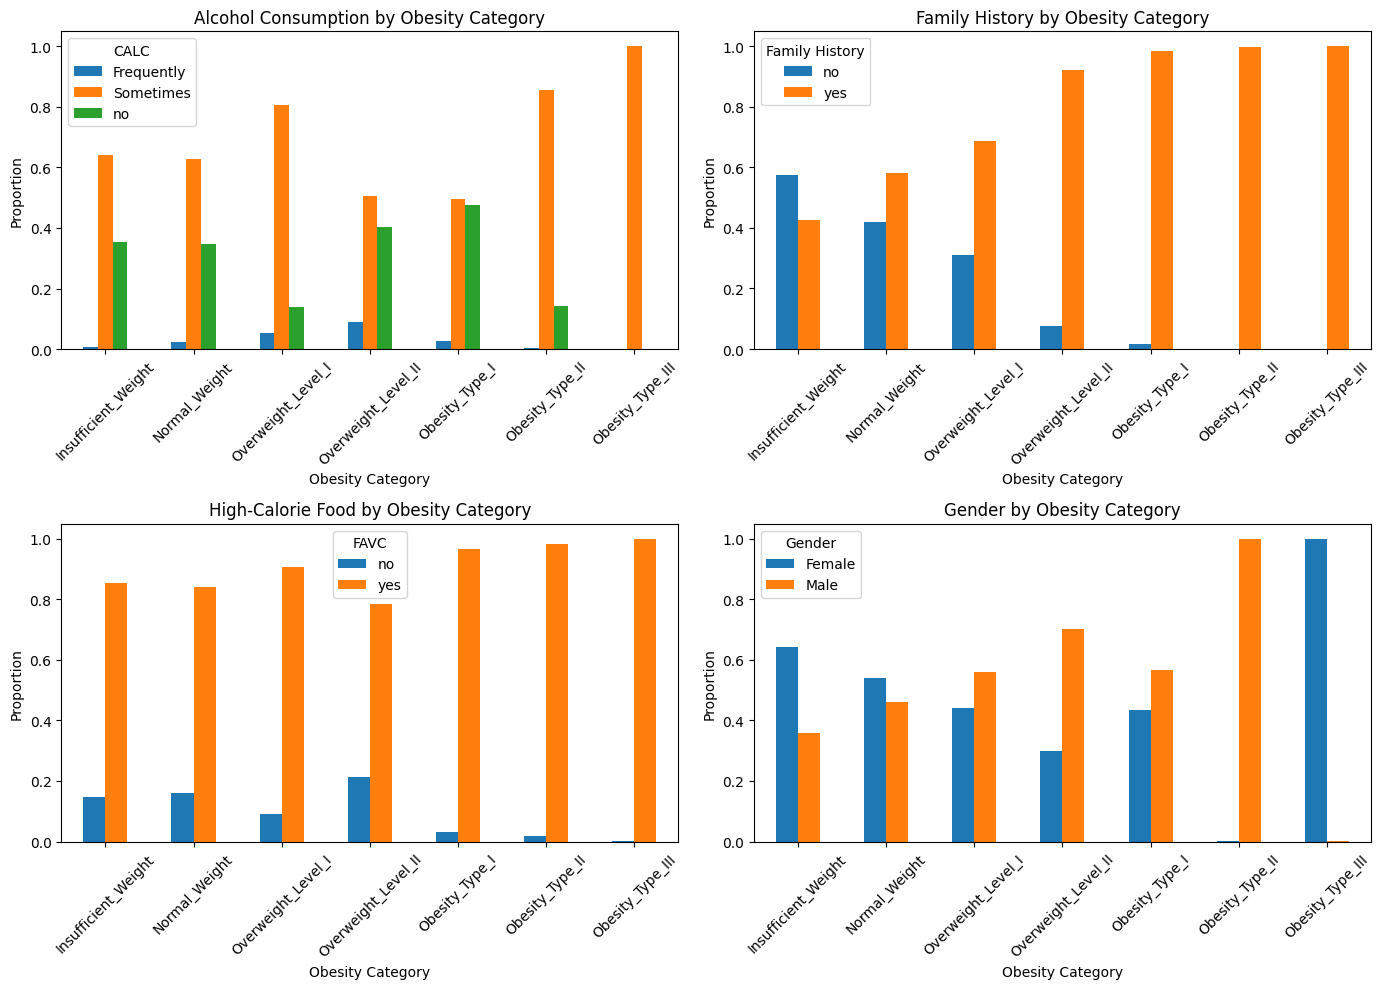

In [33]:
# Compute proportions
pivot_fh = df_train.groupby(["obesity_cat", "family_history_with_overweight"], observed=True).size().unstack(fill_value=0)
pivot_fh = pivot_fh.reindex(order).div(pivot_fh.sum(axis=1), axis=0)
pivot_favc = df_train.groupby(["obesity_cat", "FAVC"], observed=True).size().unstack(fill_value=0)
pivot_favc = pivot_favc.reindex(order).div(pivot_favc.sum(axis=1), axis=0)
pivot_gender = df_train.groupby(["obesity_cat", "Gender"], observed=True).size().unstack(fill_value=0)
pivot_gender = pivot_gender.reindex(order).div(pivot_gender.sum(axis=1), axis=0)
pivot_calc = (df_train.groupby(["obesity_cat", "CALC"], observed=True).size().unstack(fill_value=0))
pivot_calc = pivot_calc.reindex(order).div(pivot_calc.sum(axis=1), axis=0)

# Plotting in a 2×2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# 1) Age Distribution
axes[0].hist(df_train["Age"], bins=30)
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Frequency")

# 2) BMI Distribution
axes[1].hist(df_train["BMI"], bins=30)
axes[1].set_title("BMI Distribution")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Frequency")

# 3) Age by Obesity Category
df_train.boxplot(column="Age", by="obesity_cat", ax=axes[2], grid=False)
axes[2].set_title("Age by Obesity Category")
axes[2].set_xlabel("Obesity Category")
axes[2].set_ylabel("Age")
axes[2].tick_params(axis='x', rotation=45)

# 4) BMI by Obesity Category
df_train.boxplot(column="BMI", by="obesity_cat", ax=axes[3], grid=False)
axes[3].set_title("BMI by Obesity Category")
axes[3].set_xlabel("Obesity Category")
axes[3].set_ylabel("BMI")
axes[3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Plotting in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Alcohol consumption
pivot_calc.plot(kind="bar", ax=axes[0])
axes[0].set_title("Alcohol Consumption by Obesity Category")
axes[0].set_xlabel("Obesity Category")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="CALC")

# Family history
pivot_fh.plot(kind="bar", ax=axes[1])
axes[1].set_title("Family History by Obesity Category")
axes[1].set_xlabel("Obesity Category")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title="Family History")

# High-calorie food
pivot_favc.plot(kind="bar", ax=axes[2])
axes[2].set_title("High-Calorie Food by Obesity Category")
axes[2].set_xlabel("Obesity Category")
axes[2].set_ylabel("Proportion")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(title="FAVC")

# Gender
pivot_gender.plot(kind="bar", ax=axes[3])
axes[3].set_title("Gender by Obesity Category")
axes[3].set_xlabel("Obesity Category")
axes[3].set_ylabel("Proportion")
axes[3].tick_params(axis='x', rotation=45)
axes[3].legend(title="Gender")

plt.tight_layout()
plt.show()

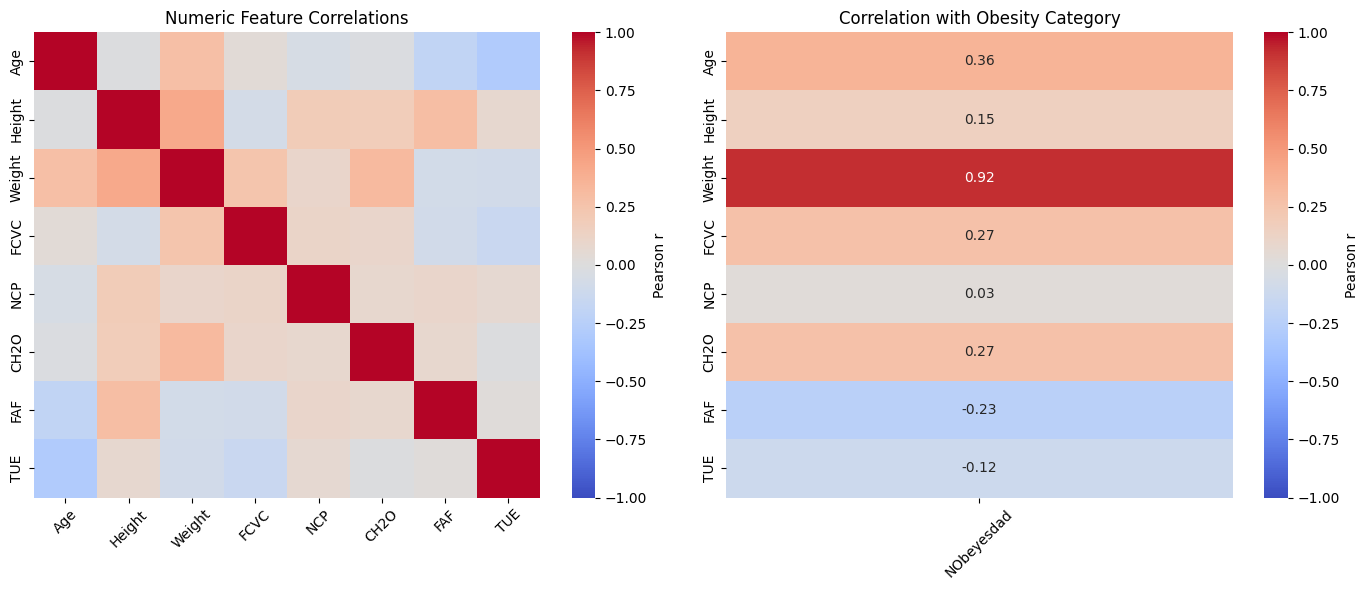

In [34]:
# 1) Ensure target is ordered categorical
order = [
    "Insufficient_Weight", "Normal_Weight",
    "Overweight_Level_I", "Overweight_Level_II",
    "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"
]
df_train["NObeyesdad"] = pd.Categorical(
    df_train["NObeyesdad"], categories=order, ordered=True
)
df_train["obesity_code"] = df_train["NObeyesdad"].cat.codes

# 2) Define numeric predictors
num_preds = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

# 3a) Full numeric-feature correlation matrix
corr_matrix = df_train[num_preds].corr()

# 3b) Correlation of each numeric feature with the response
corr_with_target = df_train[num_preds].corrwith(df_train["obesity_code"])
corr_df = corr_with_target.to_frame(name="r").loc[num_preds]

# 4) Create a side-by-side 1×2 figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 5) Plot the numeric-numeric correlation heatmap
sns.heatmap(
    corr_matrix,
    ax=axes[0],
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    xticklabels=num_preds,
    yticklabels=num_preds,
    cbar_kws={"label": "Pearson r"}
)
axes[0].set_title("Numeric Feature Correlations")
axes[0].tick_params(axis="x", rotation=45)

# 6) Plot the feature–response correlation heatmap
sns.heatmap(
    corr_df,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    yticklabels=num_preds,
    xticklabels=["NObeyesdad"],
    cbar_kws={"label": "Pearson r"}
)
axes[1].set_title("Correlation with Obesity Category")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [35]:
results_cat = []

# 1) CATEGORICAL predictors
cat_preds = ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

for var in cat_preds:
    table = pd.crosstab(df_train[var], df_train['obesity_cat'])
    chi2, p, _, _ = chi2_contingency(table)
    v = cramers_v(table)
    results_cat.append({
        'predictor': var,
        'type': 'categorical',
        'statistic': chi2,
        'p_value': p,
        'effect_size': v
    })

In [36]:
results_num = []

# 2) NUMERICAL predictors
num_preds = ['Age', 'BMI', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

for var in num_preds:
    groups = [group[var].dropna().values for _, group in df_train.groupby('obesity_cat', observed = True)]
    F, p = f_oneway(*groups)
    # eta-squared = SS_between / SS_total
    grand_mean = df_train[var].mean()
    ss_between = sum(
        len(g)*((g.mean() - grand_mean)**2)
        for g in [group[var] for _, group in df_train.groupby('obesity_cat', observed = True)]
    )
    ss_total = ((df_train[var] - grand_mean)**2).sum()
    eta2 = ss_between / ss_total
    results_num.append({
        'predictor': var,
        'type': 'numerical',
        'statistic': F,
        'p_value': p,
        'effect_size': eta2
    })

In [37]:
# 3) Compile & sort
results = results_cat + results_num
res_df = pd.DataFrame(results)
res_df = res_df.sort_values('effect_size', ascending=False).reset_index(drop=True)

# 4) Display the top predictors
res_df

# All statistically signficiant but some have higher effect size which indicate stronger association
# I used ANOVA for numerical data and chi^2 for the categorical
# BMI, Gender, family history, CAEC, and CALC are the leading strongest associations

,predictor,type,statistic,p_value,effect_size
0,BMI,numerical,47680.159499,0.000000e+00,0.932370
1,Gender,categorical,7953.767544,0.000000e+00,0.619004
2,family_history_with_overweight,categorical,6423.317091,0.000000e+00,0.556272
3,CAEC,categorical,6897.329566,0.000000e+00,0.332803
4,CALC,categorical,4013.082706,0.000000e+00,0.310908
5,FCVC,numerical,1551.918278,0.000000e+00,0.309738
6,FAVC,categorical,1553.629751,0.000000e+00,0.273578
7,SCC,categorical,1024.798467,3.870103e-218,0.222191
8,Age,numerical,962.936496,0.000000e+00,0.217788
9,MTRANS,categorical,2349.082568,0.000000e+00,0.168200


In [38]:
# Build X, y
X = df_train.drop(["NObeyesdad"], axis = 1)
y = df_train["NObeyesdad"]

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4) Preprocessing for numeric + categorical
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_preds),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_preds)
])

## Random Forest

Validation accuracy: 0.8841522157996147
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.93      0.93       505
      Normal_Weight       0.84      0.88      0.86       617
     Obesity_Type_I       0.85      0.85      0.85       582
    Obesity_Type_II       0.95      0.96      0.95       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.79      0.71      0.74       485
Overweight_Level_II       0.76      0.77      0.77       504

           accuracy                           0.88      4152
          macro avg       0.87      0.87      0.87      4152
       weighted avg       0.88      0.88      0.88      4152



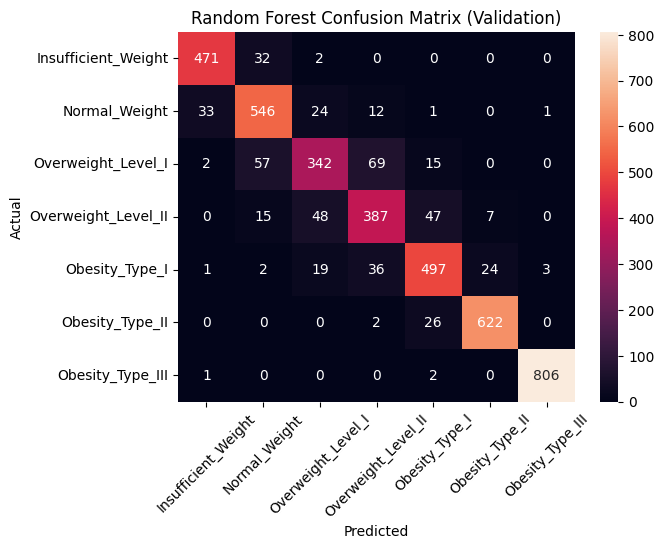

In [39]:
# 5) Pipeline with a Random Forest classifier
rf_pipeline = Pipeline([
    ("preproc", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators = 200,
        random_state=42))
])

# 6) Fit on the training split only
rf_pipeline.fit(X_train, y_train)

# 7) Evaluate on the validation set
y_val_pred = rf_pipeline.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# 8) Confusion matrix on validation
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred, labels=order)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=order, yticklabels=order)
plt.title("Random Forest Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# 9) Retrain on the full training data only after all validation is done
rf_pipeline.fit(X, y)

# 10) Final test‐set predictions
X_test_rf = df_test[num_preds + cat_preds]
test_preds_rf = rf_pipeline.predict(X_test_rf)

In [40]:
# Define Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_pipeline,
    df_train[num_preds+cat_preds],
    df_train["NObeyesdad"],
    cv=skf,
    scoring="accuracy", # n_jobs=-1
)

print(f"Random Forest 5-Fold Stratified CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Random Forest 5-Fold Stratified CV Accuracy: 0.876 ± 0.005


## Logistic Regression

Validation accuracy: 0.8586223506743738
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.95      0.92       505
      Normal_Weight       0.86      0.81      0.83       617
     Obesity_Type_I       0.81      0.80      0.80       582
    Obesity_Type_II       0.90      0.95      0.93       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.73      0.70      0.72       485
Overweight_Level_II       0.72      0.71      0.72       504

           accuracy                           0.86      4152
          macro avg       0.84      0.84      0.84      4152
       weighted avg       0.86      0.86      0.86      4152



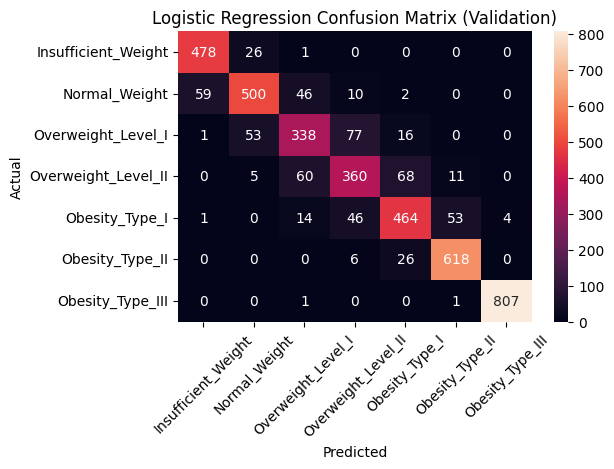

In [41]:
# 3) Logistic Regression pipeline
lr_pipeline = Pipeline([
    ("preproc", preprocessor),
    ("clf", LogisticRegression(
        multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42
    ))
])

# 4) Train on the training split only
lr_pipeline.fit(X_train, y_train)

# 5) Evaluate on the validation set
y_val_pred = lr_pipeline.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# 6) Confusion matrix on validation
cm = confusion_matrix(y_val, y_val_pred, labels=order)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=order,
    yticklabels=order
)
plt.title("Logistic Regression Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 7) After validation, retrain on the full training data
lr_pipeline.fit(X, y)

# 8) Final test‐set predictions
X_test = df_test[num_preds + cat_preds]
test_preds = lr_pipeline.predict(X_test)

In [42]:
cv_scores = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=skf,
    scoring="accuracy", # n_jobs=-1
)

# Print results
print(f"Logistic Regression 5-Fold Stratified CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Logistic Regression 5-Fold Stratified CV Accuracy: 0.852 ± 0.006


## Decision Tree

Validation accuracy: 0.8176782273603083
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.87      0.88       505
      Normal_Weight       0.77      0.78      0.77       617
     Obesity_Type_I       0.76      0.76      0.76       582
    Obesity_Type_II       0.92      0.94      0.93       650
   Obesity_Type_III       0.99      0.99      0.99       809
 Overweight_Level_I       0.63      0.61      0.62       485
Overweight_Level_II       0.64      0.65      0.64       504

           accuracy                           0.82      4152
          macro avg       0.80      0.80      0.80      4152
       weighted avg       0.82      0.82      0.82      4152



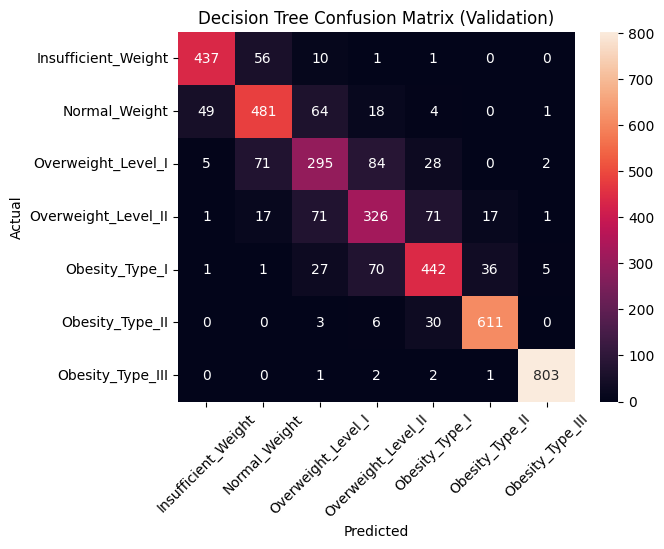

In [ ]:
# Decision Tree Pipeline
dt_pipeline = Pipeline([
    ("preproc", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=42))
])

# 1) Fit on train only
dt_pipeline.fit(X_train, y_train)

# 2) Evaluate and get confusion on hold‐out
y_val_pred = dt_pipeline.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))
cm = confusion_matrix(y_val, y_val_pred, labels=order)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=order, yticklabels=order)
plt.title("Decision Tree Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# 3) Only after all validation is done, retrain on all data
dt_pipeline.fit(X, y)
test_preds = dt_pipeline.predict(X_test)

In [44]:
cv_scores = cross_val_score(
    dt_pipeline,
    X,
    y,
    cv=skf,
    scoring="accuracy", # n_jobs=-1
)

# Print results
print(f"Decision Tree 5-Fold Stratified CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Decision Tree 5-Fold Stratified CV Accuracy: 0.819 ± 0.005


## LightGBM

Validation accuracy: 0.891859344894027
                     precision    recall  f1-score   support

Insufficient_Weight       0.93      0.94      0.93       505
      Normal_Weight       0.86      0.88      0.87       617
     Obesity_Type_I       0.85      0.87      0.86       582
    Obesity_Type_II       0.96      0.96      0.96       650
   Obesity_Type_III       1.00      1.00      1.00       809
 Overweight_Level_I       0.78      0.74      0.76       485
Overweight_Level_II       0.79      0.77      0.78       504

           accuracy                           0.89      4152
          macro avg       0.88      0.88      0.88      4152
       weighted avg       0.89      0.89      0.89      4152



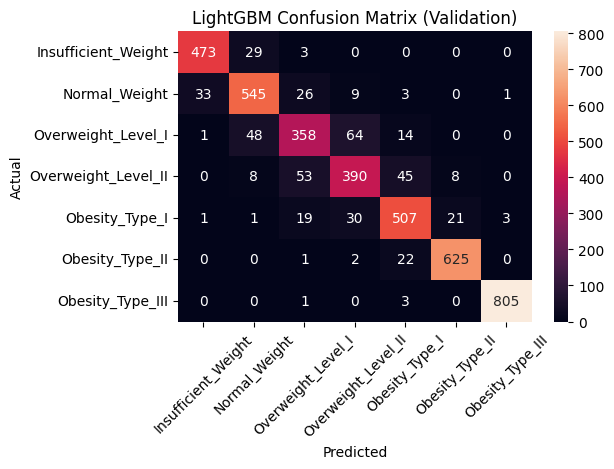

In [45]:
# By using optimized parameters found in Kaggle : https://www.kaggle.com/code/moazeldsokyx/pgs4e2-highest-score-lgbm-hyperparameter-tuning/notebook#Optimizing-Hyperparameters-for-LGBMClassifier-using-Optuna
best_params = {
    "objective": "multiclass",          # Objective function for the model
    "metric": "multi_logloss",          # Evaluation metric
    "verbosity": -1,                    # Verbosity level (-1 for silent)
    "boosting_type": "gbdt",            # Gradient boosting type
    "random_state": 42,       # Random state for reproducibility
    "num_class": 7,                     # Number of classes in the dataset
    'learning_rate': 0.030962211546832760,  # Learning rate for gradient boosting
    'n_estimators': 500,                # Number of boosting iterations
    'lambda_l1': 0.009667446568254372,  # L1 regularization term
    'lambda_l2': 0.04018641437301800,   # L2 regularization term
    'max_depth': 10,                    # Maximum depth of the trees
    'colsample_bytree': 0.40977129346872643,  # Fraction of features to consider for each tree
    'subsample': 0.9535797422450176,    # Fraction of samples to consider for each boosting iteration
    'min_child_samples': 26             # Minimum number of data needed in a leaf
}

# 7) Pipeline with tuned LightGBM
lgb_pipeline = Pipeline([
    ("preproc", preprocessor),
    ("clf", LGBMClassifier(**best_params))
])

# 8) Train on the training split only
lgb_pipeline.fit(X_train, y_train)

# 9) Evaluate on the validation set
y_val_pred = lgb_pipeline.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred))

# 10) Confusion matrix on validation
cm = confusion_matrix(y_val, y_val_pred, labels=order)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=order,
    yticklabels=order
)
plt.title("LightGBM Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 11) After validation, retrain on all data for final predictions
lgb_pipeline.fit(X, y)

# 12) Final test‐set predictions
X_test = df_test[num_preds + cat_preds]
test_preds = lgb_pipeline.predict(X_test)

In [46]:
cv_scores = cross_val_score(
    lgb_pipeline,
    X,
    y,
    cv=skf,
    scoring="accuracy", # n_jobs=-1
)

# Print results
print(f"LightGBM 5-Fold Stratified CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

LightGBM 5-Fold Stratified CV Accuracy: 0.890 ± 0.004


## Confusion Matrix

In [47]:
models = {
    "LogisticRegression": lr_pipeline,
    "DecisionTree": dt_pipeline,
    "RandomForest": rf_pipeline,
    "LightGBM": lgb_pipeline
}

# For each model, fit on X_train/y_train if not already, then get proba on X_val
roc_auc_results = {}
for name, model in models.items():
    # fit if needed
    if not hasattr(model, "classes_"):
        model.fit(X_train, y_train)
    # get probability estimates for each class
    y_proba = model.predict_proba(X_val)
    
    # compute multiclass roc-auc (one-vs-rest)
    auc = roc_auc_score(
        y_val, 
        y_proba, 
        multi_class="ovr", 
        average="macro"
    )
    roc_auc_results[name] = auc

# Display results
for name, auc in roc_auc_results.items():
    print(f"{name:15s} ROC-AUC (OvR, macro): {auc:.3f}")

LogisticRegression ROC-AUC (OvR, macro): 0.978
DecisionTree    ROC-AUC (OvR, macro): 1.000
RandomForest    ROC-AUC (OvR, macro): 1.000
LightGBM        ROC-AUC (OvR, macro): 0.998


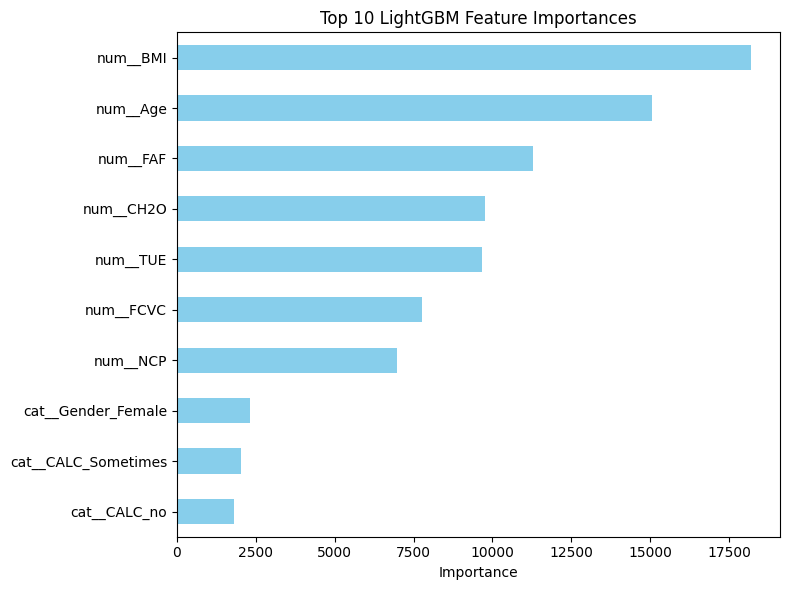

In [ ]:
# 1) Extract the trained LightGBM model from the pipeline
lgb_model = lgb_pipeline.named_steps["clf"]

# 2) Retrieve feature names after preprocessing
feature_names = lgb_pipeline.named_steps["preproc"].get_feature_names_out()

# 3) Create a Series of importances
importances = pd.Series(
    lgb_model.feature_importances_, 
    index=feature_names
).sort_values(ascending=False)

# 4) Plot the top 10 most important features
plt.figure(figsize=(8, 6))
importances.head(10).plot(kind="barh", color="skyblue")
plt.title("Top 10 LightGBM Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()  # Highest importance on top
plt.tight_layout()
plt.show()